In [26]:
# Limit CPU threads to keep runtime stable on different systems.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

RANDOM_STATE = 42


## 2. Load Dataset

In [27]:
DATA_PATH = "Epileptic Seizure Recognition.csv"

if DATA_PATH is None:
    raise FileNotFoundError(
        "CSV file was not found. Please place 'Epileptic Seizure Recognition.csv' in the same folder as this notebook."
    )

# Load the dataset into a pandas DataFrame.
data = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {data.shape[0]} rows and {data.shape[1]} columns")
display(data.head())


Dataset shape: 11500 rows and 180 columns


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37,X38,X39,X40,X41,X42,X43,X44,X45,X46,X47,X48,X49,X50,X51,X52,X53,X54,X55,X56,X57,X58,X59,X60,X61,X62,X63,X64,X65,X66,X67,X68,X69,X70,X71,X72,X73,X74,X75,X76,X77,X78,X79,X80,X81,X82,X83,X84,X85,X86,X87,X88,X89,X90,X91,X92,X93,X94,X95,X96,X97,X98,X99,X100,X101,X102,X103,X104,X105,X106,X107,X108,X109,X110,X111,X112,X113,X114,X115,X116,X117,X118,X119,X120,X121,X122,X123,X124,X125,X126,X127,X128,X129,X130,X131,X132,X133,X134,X135,X136,X137,X138,X139,X140,X141,X142,X143,X144,X145,X146,X147,X148,X149,X150,X151,X152,X153,X154,X155,X156,X157,X158,X159,X160,X161,X162,X163,X164,X165,X166,X167,X168,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,-38,-10,35,64,113,152,164,127,50,-47,-121,-138,-125,-101,-50,11,39,24,48,64,46,13,-19,-61,-96,-130,-132,-116,-115,-71,-14,25,19,6,9,21,13,-37,-58,-33,5,47,80,101,88,73,69,41,-13,-31,-61,-80,-77,-66,-43,5,87,129,121,88,12,-76,-150,-207,-186,-165,-148,-103,-33,40,94,75,8,-81,-155,-227,-262,-233,-218,-187,-126,-65,-12,27,61,49,9,-46,-124,-210,-281,-265,-181,-89,-4,53,53,38,43,31,34,9,-7,-34,-70,-84,-101,-70,-11,42,62,66,74,64,59,56,36,-11,-30,-43,-23,8,42,77,103,135,121,79,59,43,54,90,111,107,64,32,18,-25,-69,-65,-44,-33,-57,-88,-114,-130,-114,-83,-53,-79,-72,-85,-109,-98,-72,-65,-63,-11,10,8,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,232,237,258,212,2,-267,-605,-850,-1001,-1109,-1090,-967,-746,-464,-152,118,318,427,473,485,447,397,339,312,314,326,335,332,324,310,312,309,309,303,297,295,295,293,286,279,283,301,308,285,252,215,194,169,111,-74,-388,-679,-892,-949,-972,-1001,-1006,-949,-847,-668,-432,-153,72,226,326,392,461,495,513,511,496,479,453,440,427,414,399,385,385,404,432,444,437,418,392,373,363,365,372,385,388,383,371,360,353,334,303,252,200,153,151,143,48,-206,-548,-859,-1067,-1069,-957,-780,-597,-460,-357,-276,-224,-210,-350,-930,-1413,-1716,-1360,-662,-96,243,323,241,29,-167,-228,-136,27,146,229,269,297,307,303,305,306,307,280,231,159,85,51,43,62,63,63,69,89,123,136,127,102,95,105,131,163,168,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,-99,-94,-96,-104,-103,-92,-75,-69,-69,-53,-37,-14,-10,-39,-78,-102,-98,-80,-54,-40,-35,-39,-32,-13,7,34,41,33,6,-15,-30,-47,-53,-65,-64,-68,-85,-98,-109,-82,-57,-38,-40,-36,-31,-13,11,19,9,-20,-48,-71,-71,-57,-32,-13,6,29,27,25,10,-7,-36,-47,-37,-36,-22,-32,-38,-55,-61,-64,-72,-67,-53,-25,-10,-4,-23,-55,-93,-102,-106,-101,-69,-45,-42,-57,-64,-77,-80,-77,-78,-56,-34,-5,10,5,-5,-44,-75,-99,-110,-104,-103,-94,-105,-108,-110,-99,-89,-82,-76,-80,-90,-106,-106,-108,-87,-60,-37,-26,-15,-6,-14,-23,-34,-41,-54,-82,-107,-126,-124,-108,-84,-68,-61,-56,-63,-62,-33,1,28,45,37,48,62,80,66,23,-11,-39,-44,-42,-45,-48,-42,-6,29,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,-72,-68,-74,-80,-83,-73,-68,-61,-58,-59,-64,-79,-84,-97,-94,-84,-77,-75,-72,-68,-76,-76,-72,-67,-69,-69,-69,-67,-68,-69,-67,-66,-58,-54,-56,-70,-80,-82,-85,-74,-70,-71,-82,-88,-93,-97,-89,-87,-83,-70,-50,-37,-31,-32,-39,-54,-64,-68,-67,-69,-63,-60,-63,-55,-43,-37,-27,-31,-35,-47,-58,-63,-74,-73,-67,-60,-56,-49,-46,-57,-58,-62,-63,-63,-61,-56,-65,-62,-57,-61,-63,-66,-69,-86,-89,-86,-83,-87,-80,-69,-62,-57,-60,-60,-68,-58,-53,-57,-66,-66,-73,-78,-73,-84,-92,-97,-88,-81,-72,-61,-66,-72,-88,-90,-88,-77,-58,-53,-61,-69,-66,-74,-69,-61,-51,-45,-45,-49,-58,-64,-78,-80,-90,-87,-83,-78,-64,-38,-22,-29,-42,-51,-68,-71,-69,-69,-74,-74,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,-90,-103,-84,-43,-9,3,-21,-60,-96,-103,-75,-29,14,55,78,73,28,-13,-43,-68,-78,-75,-55,-41,-19,-20,-29,-36,-20,1,16,14,-14,-42,-56,-45,-45,-45,-38,-47,-45,-37,-3,23,39,27,0,-28,-44,-37,-22,5,30,31,6,-32,-27,-27,2,13,-6,-29,-41,-22,-13,-16,-31,-52,-60,-40,-16,0,14,24,36,39,3

## 3. Initial Data Understanding

In [28]:
# Check data types, and the target column.
print("\nData types:")
print(data.dtypes.value_counts())

print("\nBasic information:")
data.info()



Data types:
int64    179
str        1
Name: count, dtype: int64

Basic information:
<class 'pandas.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), str(1)
memory usage: 15.8 MB


In [29]:
# The identifier column is not useful for learning patterns so it must not enter the model
id_column = "Unnamed"
target_column = "y"

feature_columns = [col for col in data.columns if col.startswith("X")]

print(f"Number of signal features: {len(feature_columns)}")
print(f"First 10 feature columns: {feature_columns[:10]}")
print(f"Last 10 feature columns: {feature_columns[-10:]}")


Number of signal features: 178
First 10 feature columns: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']
Last 10 feature columns: ['X169', 'X170', 'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178']


## 4. Target Definition: Seizure vs Non-Seizure

In [30]:
# In this dataset, class 1 represents epileptic seizure activity.
# Classes 2, 3, 4, and 5 are treated as non-seizure conditions for binary classification.
# Binary target:
# 1 = Seizure
# 0 = Non-Seizure
data["seizure"] = data[target_column].apply(lambda value: 1 if value == 1 else 0)

label_names = {
    0: "Non-Seizure",
    1: "Seizure"
}

print("Original class distribution:")
display(data[target_column].value_counts().sort_index().rename("count").to_frame())

print("\nBinary target distribution:")
display(data["seizure"].map(label_names).value_counts().rename("count").to_frame())


Original class distribution:


,count
y,
1,2300
2,2300
3,2300
4,2300
5,2300



Binary target distribution:


,count
seizure,
Non-Seizure,9200
Seizure,2300


## 5. Data Quality Check

In [31]:
# Check missing values
missing_values = data.isnull().sum()
missing_summary = missing_values[missing_values > 0].sort_values(ascending=False)

print(f"Total missing values: {int(missing_values.sum())}")
if missing_summary.empty:
    print("No missing values were found.")
else:
    display(missing_summary.to_frame(name="missing_count"))


Total missing values: 0
No missing values were found.


In [32]:
# Check duplicated rows
duplicate_count = data.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")


Number of duplicated rows: 0


In [33]:
# Check basic statistics of signal features.
# This helps us understand the scale, spread, and possible extreme values in the EEG signals.
signal_statistics = data[feature_columns].describe().T
display(signal_statistics.head(10))


,count,mean,std,min,25%,50%,75%,max
X1,11500.0,-11.581391,165.626284,-1839.0,-54.0,-8.0,34.00,1726.0
X2,11500.0,-10.911565,166.059609,-1838.0,-55.0,-8.0,35.00,1713.0
X3,11500.0,-10.187130,163.524317,-1835.0,-54.0,-7.0,36.00,1697.0
X4,11500.0,-9.143043,161.269041,-1845.0,-54.0,-8.0,36.00,1612.0
X5,11500.0,-8.009739,160.998007,-1791.0,-54.0,-8.0,35.00,1518.0
X6,11500.0,-7.003478,161.328725,-1757.0,-54.0,-8.0,36.00,1816.0
X7,11500.0,-6.502087,161.467837,-1832.0,-54.0,-8.0,35.00,2047.0
X8,11500.0,-6.687130,162.119120,-1778.0,-55.0,-8.0,36.00,2047.0
X9,11500.0,-6.558000,162.033360,-1840.0,-55.0,-7.0,36.00,2047.0
X10,11500.0,-6.168435,160.436352,-1867.0,-54.0,-7.0,35.25,2047.0


In [ ]:
# Detect possible outliers using the IQR method 
# EEG signals can naturally contain extreme values
def count_iqr_outliers(df_features):
    outlier_rows = []
    for col in df_features.columns:
        q1 = df_features[col].quantile(0.25)
        q3 = df_features[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_count = ((df_features[col] < lower_bound) | (df_features[col] > upper_bound)).sum()
        outlier_rows.append({
            "feature": col,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(outlier_count)
        })
    return pd.DataFrame(outlier_rows)

outlier_summary = count_iqr_outliers(data[feature_columns])
display(outlier_summary.sort_values("outlier_count", ascending=False).head(10))

,feature,lower_bound,upper_bound,outlier_count
64,X65,-186.5,169.5,1336
160,X161,-184.0,168.0,1333
56,X57,-182.5,165.5,1328
155,X156,-183.5,166.5,1327
161,X162,-185.5,170.5,1327
62,X63,-185.0,167.0,1323
165,X166,-190.0,170.0,1322
61,X62,-185.0,167.0,1319
159,X160,-184.0,168.0,1319
164,X165,-186.0,166.0,1318


## 6. Exploratory Data Analysis

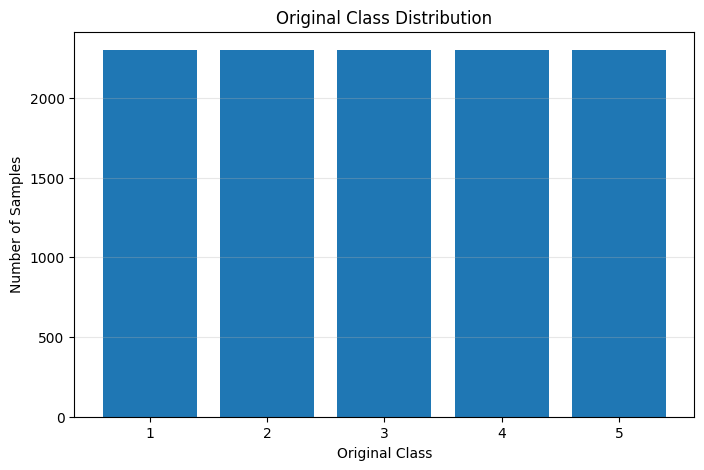

In [11]:
# Plot original 5-class distribution.
original_counts = data[target_column].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(original_counts.index.astype(str), original_counts.values)
plt.title("Original Class Distribution")
plt.xlabel("Original Class")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.3)
plt.show()


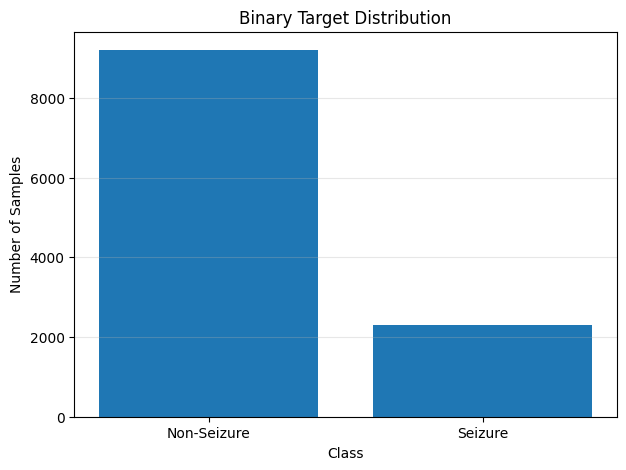

In [12]:
# Plot binary target distribution.
binary_counts = data["seizure"].map(label_names).value_counts()

plt.figure(figsize=(7, 5))
plt.bar(binary_counts.index, binary_counts.values)
plt.title("Binary Target Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.3)
plt.show()


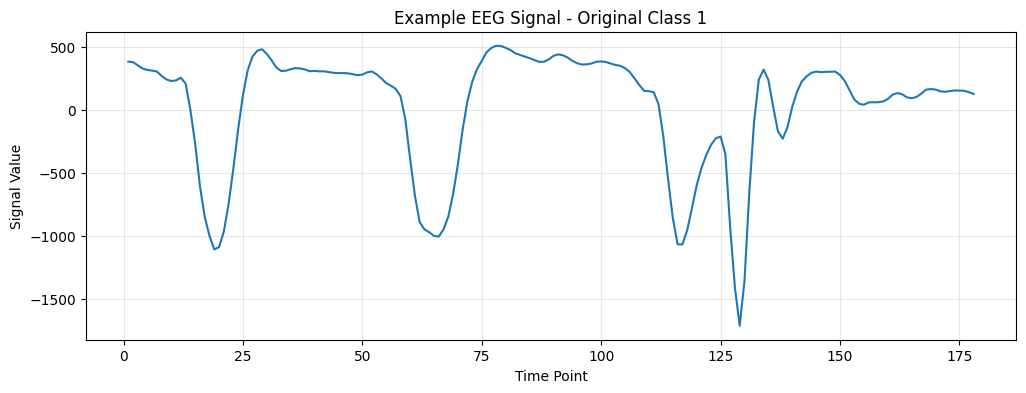

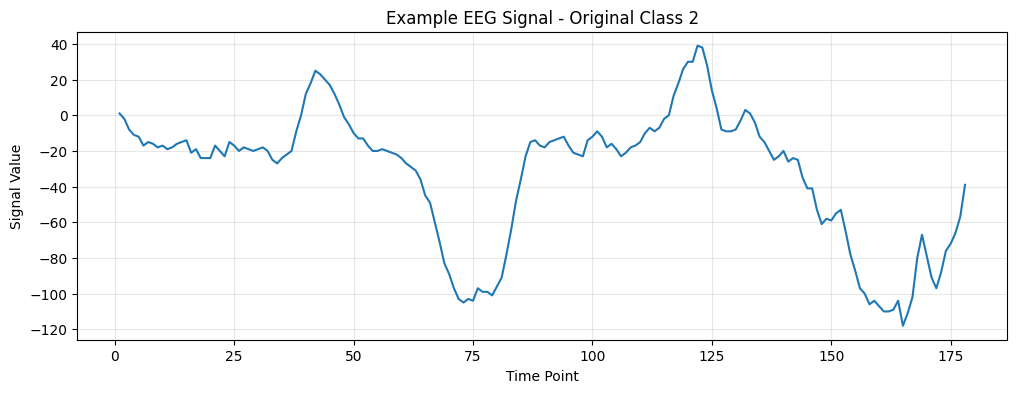

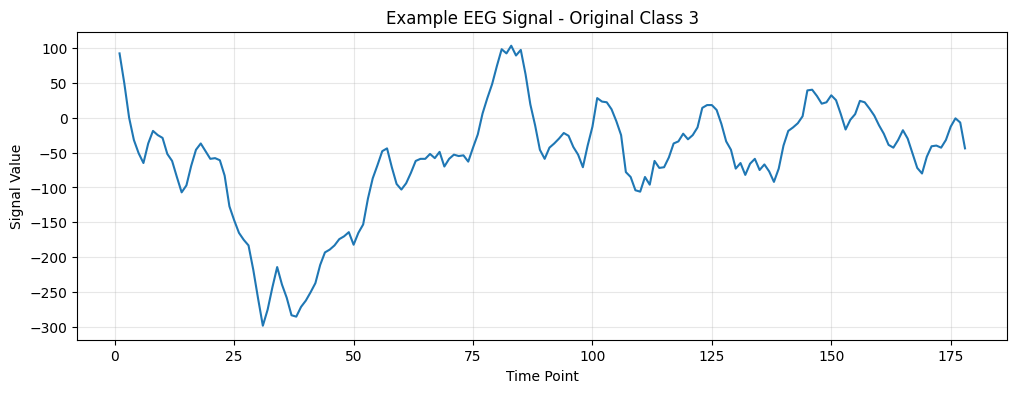

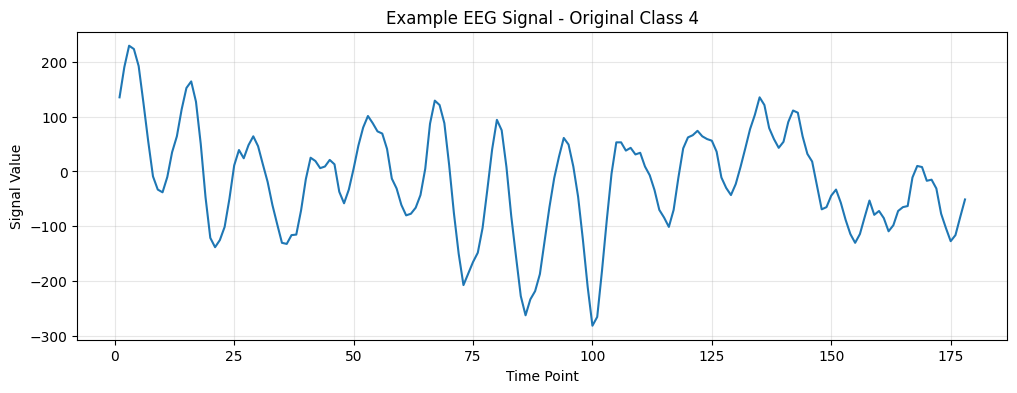

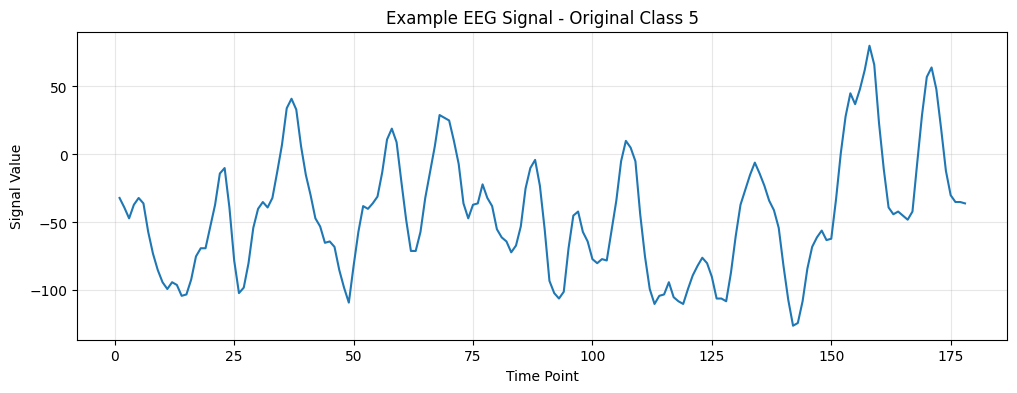

In [13]:
# Plot one EEG signal example from each original class
# Each row contains 178 consecutive EEG signal measurements
for class_value in sorted(data[target_column].unique()):
    sample_signal = data.loc[data[target_column] == class_value, feature_columns].iloc[0].values

    plt.figure(figsize=(12, 4))
    plt.plot(range(1, len(feature_columns) + 1), sample_signal)
    plt.title(f"Example EEG Signal - Original Class {class_value}")
    plt.xlabel("Time Point")
    plt.ylabel("Signal Value")
    plt.grid(alpha=0.3)
    plt.show()


,count,mean,std,min,25%,50%,75%,max
seizure,,,,,,,,
Non-Seizure,9200.0,48.339063,26.894373,9.769663,32.224719,42.69382,58.331461,381.202247
Seizure,2300.0,244.462501,121.576017,48.539326,138.192416,225.77809,335.405899,671.876404


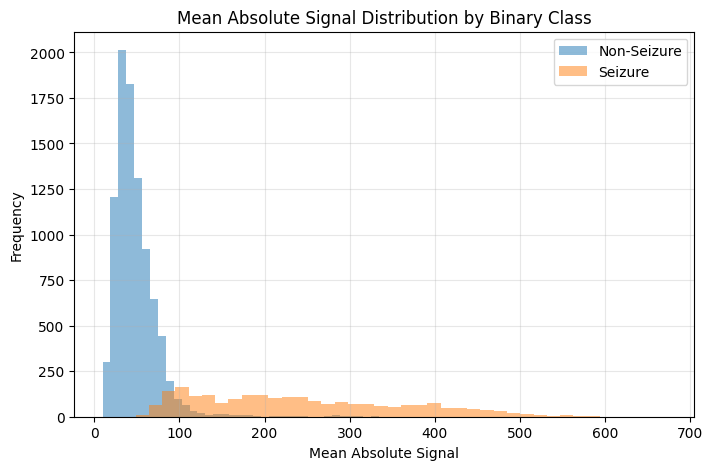

In [14]:
# Compare the average absolute signal level between seizure and non-seizure records
# This engineered value is only for analysis, not the main model input
data["mean_absolute_signal"] = data[feature_columns].abs().mean(axis=1)

summary_by_binary_class = data.groupby("seizure")["mean_absolute_signal"].describe()
summary_by_binary_class.index = summary_by_binary_class.index.map(label_names)
display(summary_by_binary_class)

plt.figure(figsize=(8, 5))
for binary_value, class_name in label_names.items():
    values = data.loc[data["seizure"] == binary_value, "mean_absolute_signal"]
    plt.hist(values, bins=40, alpha=0.5, label=class_name)

plt.title("Mean Absolute Signal Distribution by Binary Class")
plt.xlabel("Mean Absolute Signal")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


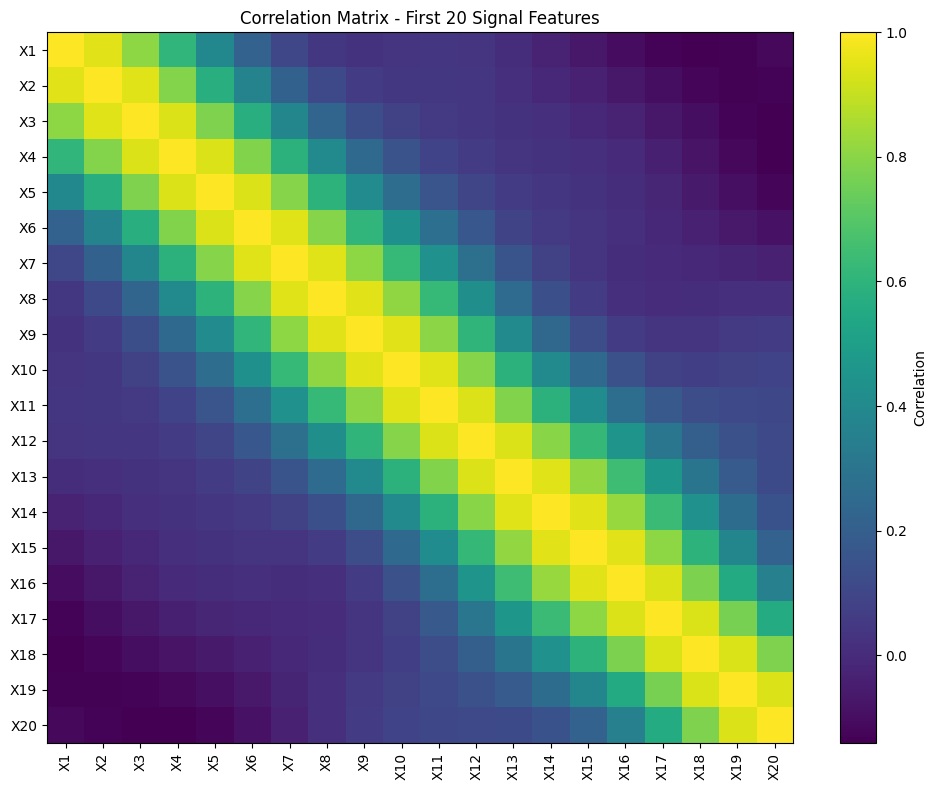

In [15]:
# Display a correlation matrix for a subset of features.
# A subset is used because all 178 features would make the heatmap hard to read.
subset_features = feature_columns[:20]
correlation_matrix = data[subset_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(subset_features)), subset_features, rotation=90)
plt.yticks(range(len(subset_features)), subset_features)
plt.title("Correlation Matrix - First 20 Signal Features")
plt.tight_layout()
plt.show()


## 7. Prepare Features and Target

In [41]:
# Create the final feature matrix X and binary target vector y
# The identifier column and target columns are excluded from X
X = data[feature_columns].copy()
y = data["seizure"].copy()
y_original = data[target_column].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\nBinary target counts:")
display(y.map(label_names).value_counts().rename("count").to_frame())


X shape: (11500, 178)
y shape: (11500,)

Binary target counts:


,count
seizure,
Non-Seizure,9200
Seizure,2300


In [42]:
# Split the data into training and test sets
# Stratification is based on the original 5-class label to preserve all original groups inside the split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_original
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print("\nTraining target distribution:")
display(y_train.map(label_names).value_counts(normalize=True).rename("ratio").to_frame())

print("\nTest target distribution:")
display(y_test.map(label_names).value_counts(normalize=True).rename("ratio").to_frame())


Training set: 9200 samples
Test set: 2300 samples

Training target distribution:


,ratio
seizure,
Non-Seizure,0.8
Seizure,0.2



Test target distribution:


,ratio
seizure,
Non-Seizure,0.8
Seizure,0.2


## 8. PCA Analysis for Dimensionality Reduction

Number of PCA components needed to keep at least 95% variance: 39


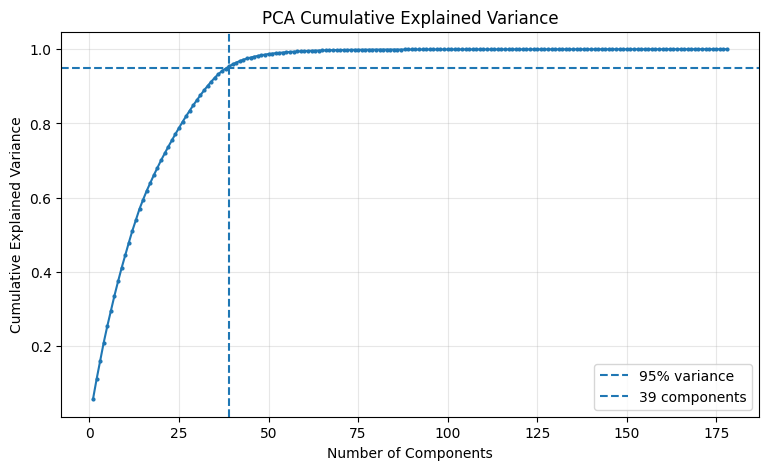

In [43]:
# PCA must be fitted only on training data to avoid data leakage
# Scaling is required before PCA because PCA is sensitive to feature scale
scaler_for_pca = StandardScaler()
X_train_scaled = scaler_for_pca.fit_transform(X_train)

pca_full = PCA()
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

print(f"Number of PCA components needed to keep at least 95% variance: {n_components_95}")

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", markersize=2)
plt.axhline(y=0.95, linestyle="--", label="95% variance")
plt.axvline(x=n_components_95, linestyle="--", label=f"{n_components_95} components")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 9. Define Machine Learning Models

In [44]:
# Logistic Regression is used as a baseline linear model
# Random Forest is used as a stronger non-linear tree-based model
# KNN is used as a distance-based model
# SVM is used as a strong margin-based non-linear model
# PCA + Logistic Regression is used to compare model performance after dimensionality reduction
# class_weight='balanced' helps supported models pay more attention to the minority seizure class

models = {
    "Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=500,
            solver="liblinear",
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("model", RandomForestClassifier(
            n_estimators=50,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1
        ))
    ]),

    "KNN": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    "SVM": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "PCA + Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, svd_solver="full")),
        ("model", LogisticRegression(
            max_iter=500,
            solver="liblinear",
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),
    "PCA + SVM" : Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ("svm", SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])
}

print("Defined models:")
for model_name in models:
    print(f"- {model_name}")

Defined models:
- Logistic Regression
- Random Forest
- KNN
- SVM
- PCA + Logistic Regression
- PCA + SVM


## 10. Train and Evaluate Models

In [45]:
# This function trains a model, predicts labels, predicts seizure probabilities, and calculates evaluation metrics
def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_seizure": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_seizure": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_seizure": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

    return model, y_pred, y_prob, metrics

trained_models = {}
predictions = {}
probabilities = {}
metrics_rows = []

for model_name, model in models.items():
    print(f"Training: {model_name}")
    trained_model, y_pred, y_prob, metrics = evaluate_model(
        model_name, model, X_train, y_train, X_test, y_test
    )

    trained_models[model_name] = trained_model
    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob
    metrics_rows.append(metrics)

metrics_df = pd.DataFrame(metrics_rows).sort_values(
    by=["recall_seizure", "roc_auc", "f1_seizure"],
    ascending=False
)

display(metrics_df)


Training: Logistic Regression
Training: Random Forest
Training: KNN
Training: SVM
Training: PCA + Logistic Regression
Training: PCA + SVM


,model,accuracy,balanced_accuracy,precision_seizure,recall_seizure,f1_seizure,roc_auc
3,SVM,0.976087,0.974457,0.914110,0.971739,0.942044,0.995862
5,PCA + SVM,0.975652,0.974185,0.912245,0.971739,0.941053,0.995721
1,Random Forest,0.974783,0.950000,0.963134,0.908696,0.935123,0.996155
2,KNN,0.927826,0.820380,0.996622,0.641304,0.780423,0.920870
0,Logistic Regression,0.687826,0.602717,0.310850,0.460870,0.371278,0.534278
4,PCA + Logistic Regression,0.601739,0.545652,0.238532,0.452174,0.312312,0.507365


In [53]:
# Print a detailed classification report for each trained model
for model_name in trained_models:
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(classification_report(
        y_test,
        predictions[model_name],
        target_names=["Non-Seizure", "Seizure"],
        digits=4
    ))


Logistic Regression
              precision    recall  f1-score   support

 Non-Seizure     0.8467    0.7446    0.7924      1840
     Seizure     0.3109    0.4609    0.3713       460

    accuracy                         0.6878      2300
   macro avg     0.5788    0.6027    0.5818      2300
weighted avg     0.7395    0.6878    0.7081      2300

Random Forest
              precision    recall  f1-score   support

 Non-Seizure     0.9775    0.9913    0.9843      1840
     Seizure     0.9631    0.9087    0.9351       460

    accuracy                         0.9748      2300
   macro avg     0.9703    0.9500    0.9597      2300
weighted avg     0.9746    0.9748    0.9745      2300

KNN
              precision    recall  f1-score   support

 Non-Seizure     0.9177    0.9995    0.9568      1840
     Seizure     0.9966    0.6413    0.7804       460

    accuracy                         0.9278      2300
   macro avg     0.9571    0.8204    0.8686      2300
weighted avg     0.9335    0.9278   

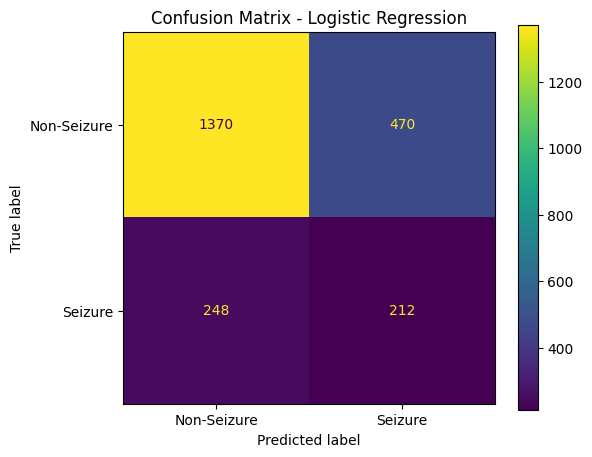

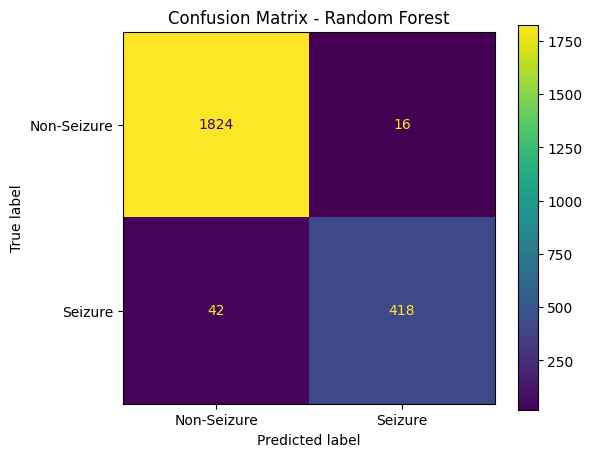

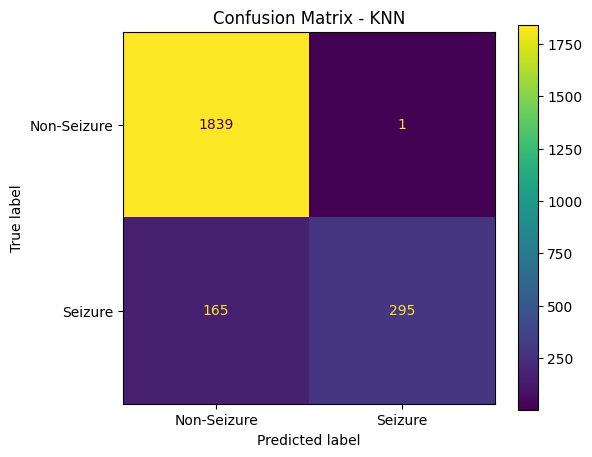

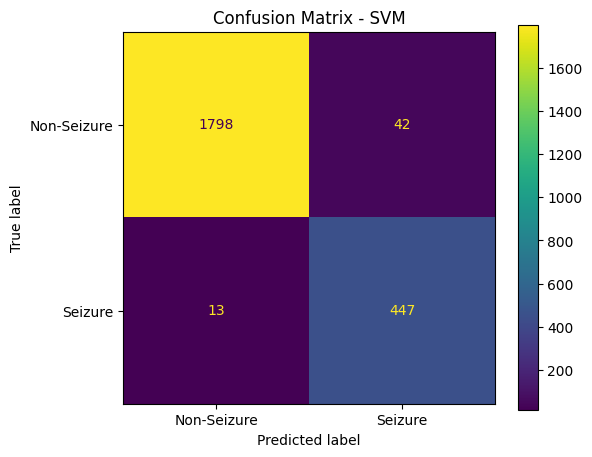

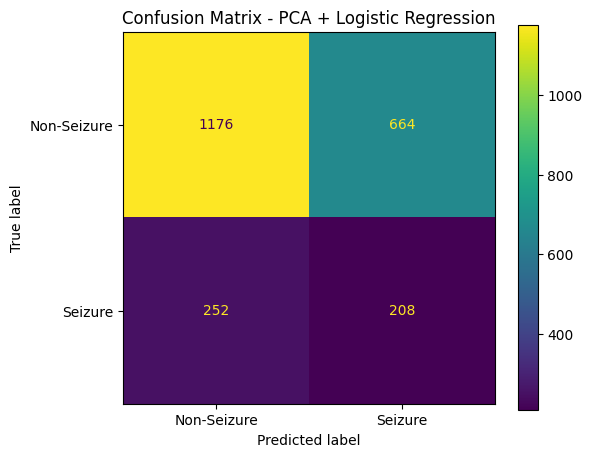

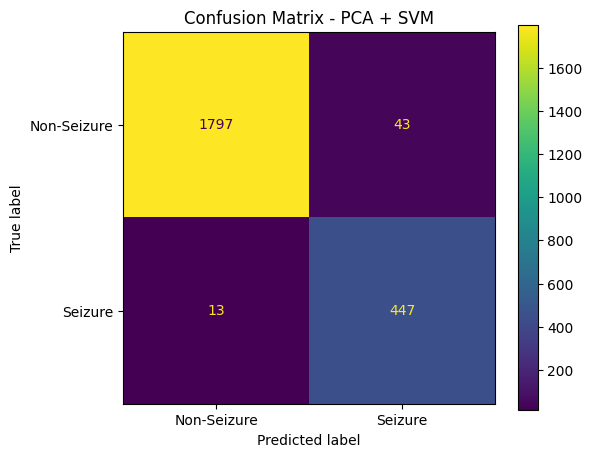

In [54]:
# Plot a separate confusion matrix for each model.
# Rows show actual classes and columns show predicted classes.
for model_name in trained_models:
    cm = confusion_matrix(y_test, predictions[model_name])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Seizure", "Seizure"]
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.grid(False)
    plt.show()


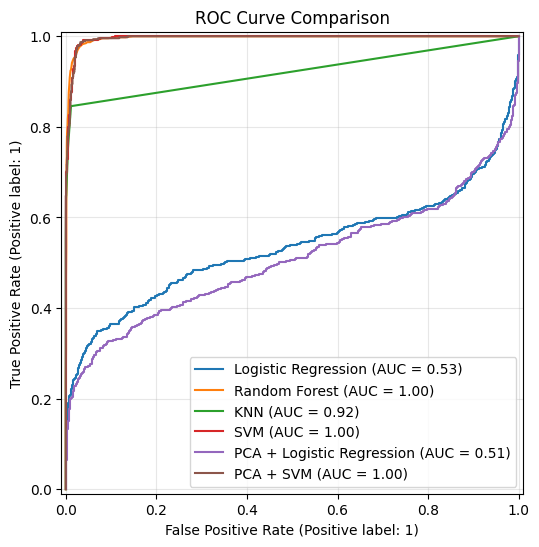

In [55]:
# Plot ROC curves for all models in one figure for easy comparison.
plt.figure(figsize=(8, 6))

for model_name in trained_models:
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities[model_name],
        name=model_name,
        ax=plt.gca()
    )

plt.title("ROC Curve Comparison")
plt.grid(alpha=0.3)
plt.show()


## 11. Select the Best Model

In [56]:
# In a healthcare task, seizure recall is very important because missing a seizure case can be dangerous.
# Therefore, the best model is selected by seizure recall first, then ROC-AUC, then F1-score.
best_model_name = metrics_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_probabilities = probabilities[best_model_name]

print(f"Best model based on seizure recall, ROC-AUC, and F1-score: {best_model_name}")
display(metrics_df[metrics_df["model"] == best_model_name])


Best model based on seizure recall, ROC-AUC, and F1-score: SVM


,model,accuracy,balanced_accuracy,precision_seizure,recall_seizure,f1_seizure,roc_auc
3,SVM,0.976087,0.974457,0.91411,0.971739,0.942044,0.995862


## 12. Threshold Tuning for Seizure Probability

### Threshold Tuning Analysis

The model can output seizure probabilities.  
A threshold converts these probabilities into final class labels.

In this section, different thresholds are tested to keep seizure recall at least 0.95.  
Among valid thresholds, the one with the best precision is selected.

This helps analyze the trade-off between detecting more seizure cases and reducing false alarms.  
The tuned threshold is compared with the default SVM prediction before choosing the final model.

Selected threshold: 0.3557
Target recall: 0.95

Evaluation after threshold tuning:
              precision    recall  f1-score   support

 Non-Seizure     0.9885    0.9804    0.9844      1840
     Seizure     0.9242    0.9543    0.9390       460

    accuracy                         0.9752      2300
   macro avg     0.9564    0.9674    0.9617      2300
weighted avg     0.9756    0.9752    0.9754      2300



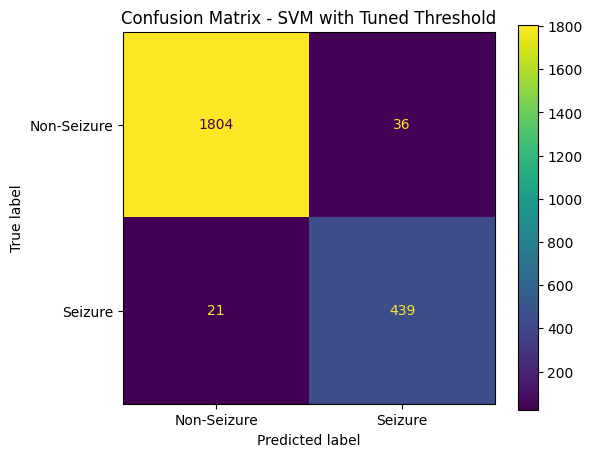

In [57]:
# The default classification threshold is 0.50
# In medical problems, we may lower the threshold to increase seizure recall
# This section searches for a threshold that keeps recall at or above the target value when possible
target_recall = 0.95

precision_values, recall_values, threshold_values = precision_recall_curve(y_test, best_probabilities)

threshold_table = pd.DataFrame({
    "threshold": threshold_values,
    "precision": precision_values[:-1],
    "recall": recall_values[:-1]
})

valid_thresholds = threshold_table[threshold_table["recall"] >= target_recall]

if not valid_thresholds.empty:
    tuned_threshold = float(valid_thresholds.sort_values(
        by=["precision", "threshold"],
        ascending=False
    ).iloc[0]["threshold"])
else:
    tuned_threshold = 0.50

print(f"Selected threshold: {tuned_threshold:.4f}")
print(f"Target recall: {target_recall}")

y_pred_tuned = (best_probabilities >= tuned_threshold).astype(int)

print("\nEvaluation after threshold tuning:")
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Non-Seizure", "Seizure"],
    digits=4
))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["Non-Seizure", "Seizure"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
plt.title(f"Confusion Matrix - {best_model_name} with Tuned Threshold")
plt.grid(False)
plt.show()


## 13. Predict Patient Condition and Seizure Probability

In [58]:
# This helper function returns the final class label and seizure probability.
# The final class label is generated using the model's default prediction behavior.
def predict_patient_condition(model, patient_records):
    """
    Predict seizure condition and seizure probability for one or more patient records.

    Parameters
    ----------
    model : trained sklearn model or pipeline
        The trained classification model.
    patient_records : pandas DataFrame
        Patient records with the same feature columns used during training.

    Returns
    -------
    pandas DataFrame
        A table containing predicted class and seizure probability.
    """
    predicted_binary = model.predict(patient_records)
    seizure_probability = model.predict_proba(patient_records)[:, 1]
    predicted_label = [label_names[value] for value in predicted_binary]

    return pd.DataFrame({
        "predicted_label": predicted_label,
        "seizure_probability": seizure_probability
    })


# Demonstrate prediction on the first 10 test records.
sample_patients = X_test.iloc[:10].copy()
sample_actual = y_test.iloc[:10].map(label_names).reset_index(drop=True)

sample_predictions = predict_patient_condition(
    best_model,
    sample_patients
)

sample_predictions.insert(0, "actual_label", sample_actual)
display(sample_predictions)

,actual_label,predicted_label,seizure_probability
0,Seizure,Seizure,0.994200
1,Non-Seizure,Non-Seizure,0.003049
2,Seizure,Seizure,0.994648
3,Seizure,Seizure,0.989208
4,Non-Seizure,Non-Seizure,0.009003
5,Seizure,Non-Seizure,0.098151
6,Non-Seizure,Non-Seizure,0.012836
7,Non-Seizure,Non-Seizure,0.009510
8,Non-Seizure,Non-Seizure,0.005657
9,Non-Seizure,Non-Seizure,0.006321


## 14. Save the Final Model

In [59]:
# Save the final model together with feature column order and label mapping.
# This makes future prediction safer because the feature order must remain the same.
model_artifact = {
    "model": best_model,
    "decision_method": "default_svm_predict",
    "feature_columns": feature_columns,
    "label_names": label_names,
    "best_model_name": best_model_name
}

output_model_path = Path("seizure_detection_model.joblib")
joblib.dump(model_artifact, output_model_path)

print(f"Model artifact saved to: {output_model_path.resolve()}")

Model artifact saved to: D:\DM\final project\seizure_detection_model.joblib


## 15. Final Summary Tables

In [60]:
# Final model comparison table.
display(metrics_df)

# Final selected model information.
final_summary = pd.DataFrame({
    "item": [
        "Selected model",
        "Target class",
    ],
    "value": [
        best_model_name,
        "Seizure = 1, Non-Seizure = 0",
    ]
})

final_summary


,model,accuracy,balanced_accuracy,precision_seizure,recall_seizure,f1_seizure,roc_auc
3,SVM,0.976087,0.974457,0.914110,0.971739,0.942044,0.995862
5,PCA + SVM,0.975652,0.974185,0.912245,0.971739,0.941053,0.995721
1,Random Forest,0.974783,0.950000,0.963134,0.908696,0.935123,0.996155
2,KNN,0.927826,0.820380,0.996622,0.641304,0.780423,0.920870
0,Logistic Regression,0.687826,0.602717,0.310850,0.460870,0.371278,0.534278
4,PCA + Logistic Regression,0.601739,0.545652,0.238532,0.452174,0.312312,0.507365


,item,value
0,Selected model,SVM
1,Target class,"Seizure = 1, Non-Seizure = 0"
